# 1) Setup + helpers

Prepare a Colab environment to load time‑series data from a 384‑well plate (A–P × 1–24), reorder it into a consistent well order, and browse it over time as a heatmap with a slider.



In [ ]:
# @title
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display, Markdown
from google.colab import files
import ipywidgets as widgets

# # --- Install TRUE Arial (Method: download + extract) ---
# # (No interactive EULA; works reliably in Colab.)
# !apt-get update -y >/dev/null
# !apt-get install -y cabextract fontconfig >/dev/null
# !rm -rf /usr/share/fonts/truetype/msttcorefonts
# !mkdir -p /usr/share/fonts/truetype/msttcorefonts

# # Download the corefonts archives that contain Arial
# !wget -q -O /content/arial32.exe  https://downloads.sourceforge.net/corefonts/arial32.exe
# !wget -q -O /content/arialb32.exe https://downloads.sourceforge.net/corefonts/arialb32.exe || true
# !wget -q -O /content/ari32.exe    https://downloads.sourceforge.net/corefonts/ari32.exe    || true

# # Extract TTFs into the system fonts directory
# !cabextract -q -d /usr/share/fonts/truetype/msttcorefonts /content/arial32.exe  || true
# !cabextract -q -d /usr/share/fonts/truetype/msttcorefonts /content/arialb32.exe || true
# !cabextract -q -d /usr/share/fonts/truetype/msttcorefonts /content/ari32.exe    || true

# # Rebuild OS font cache
# !fc-cache -f -v >/dev/null

# # --- Register Arial with Matplotlib & set as default (incl. mathtext) ---
# FONT_DIR = "/usr/share/fonts/truetype/msttcorefonts"
# for fname in ("Arial.TTF","Arialbd.TTF","Ariali.TTF","Arialbi.TTF","AriBlk.TTF"):
#     path = os.path.join(FONT_DIR, fname)
#     if os.path.exists(path):
#         fm.fontManager.addfont(path)

# # Force a fresh font scan in this Python process
# fm._load_fontmanager(try_read_cache=False)

# # Use Arial everywhere
# plt.rcParams.update({
#     "font.family": "Arial",
#     "mathtext.fontset": "custom",
#     "mathtext.rm": "Arial",
#     "mathtext.it": "Arial:italic",
#     "mathtext.bf": "Arial:bold",
# })

# Optional: sharper inline rendering
# %config InlineBackend.figure_format = 'retina'

# --- Plate layout helpers ---
ROWS = list("ABCDEFGHIJKLMNOP")         # 16 rows
COLS = list(range(1, 25))               # 24 cols
EXPECTED_WELLS = [f"{r}{c}" for r in ROWS for c in COLS]  # A1..A24 ... P1..P24

def _read_table(path):
    ext = os.path.splitext(path)[1].lower()

    # Excel files: pick the sheet with the most well headers
    if ext in [".xlsx", ".xls"]:
        xls = pd.ExcelFile(path)
        best_sheet, best_count = None, -1
        for sh in xls.sheet_names:
            try:
                tmp = pd.read_excel(xls, sheet_name=sh, nrows=3)
            except Exception:
                continue
            cols = [str(c).strip() for c in tmp.columns]
            count = sum(c in EXPECTED_WELLS for c in cols)
            if count > best_count:
                best_sheet, best_count = sh, count
        return pd.read_excel(xls, sheet_name=best_sheet)

    # CSV/TSV/TXT files
    elif ext in [".csv", ".tsv", ".txt"]:
        sep = "," if ext == ".csv" else ("\t" if ext == ".tsv" else None)
        return pd.read_csv(path, sep=sep)

    else:
        raise ValueError("Unsupported file type (use .xlsx, .xls, .csv, .tsv, or .txt)")

def load_384_table(path_or_df):
    """
    Returns (df_ordered, wells_list).
    - Rows = time points
    - Columns = wells A1..A24 ... P1..P24 (reordered; extras ignored)
    - If time is in columns (384 rows), auto-transpose.
    """
    if isinstance(path_or_df, pd.DataFrame):
        df = path_or_df.copy()
    else:
        df = _read_table(path_or_df)

    df.columns = [str(c).strip() for c in df.columns]

    # If wells are rows, flip so time is rows
    if df.shape[0] == 384 and df.shape[1] != 384:
        df = df.transpose()
        df.columns = [str(c).strip() for c in df.columns]

    present = [w for w in EXPECTED_WELLS if w in df.columns]
    if not present:
        raise ValueError("Did not find well headers like 'A1'...'P24'.")
    if len(present) < 384:
        missing = [w for w in EXPECTED_WELLS if w not in df.columns]
        display(Markdown(f"**Warning:** {len(missing)} wells missing. First few: {missing[:10]}"))

    return df[present].copy(), present


def reshape_to_plate(row_values, wells_order):
    """1D vector (len ≤ 384) → 16×24 array in A..P × 1..24 order."""
    plate = np.full((len(ROWS), len(COLS)), np.nan, float)
    grid = np.array(EXPECTED_WELLS).reshape(len(ROWS), len(COLS))
    series = pd.Series(row_values, index=wells_order)
    for i in range(len(ROWS)):
        for j in range(len(COLS)):
            label = grid[i, j]
            if label in series.index:
                plate[i, j] = series[label]
    return plate

def time_scroller(df, wells_order, title, vmin=None, vmax=None, unit="RFU"):
    """Interactive heatmap per time index (uses global Arial)."""
    # Precompute 3D stack for speed
    stack = np.asarray([reshape_to_plate(df.iloc[t].values, wells_order) for t in range(len(df))])
    if vmin is None: vmin = np.nanmin(stack)
    if vmax is None: vmax = np.nanmax(stack)

    def _draw(t):
        fz = 25
        fig, ax = plt.subplots(figsize=(9, 4.8), dpi=100)
        im = ax.imshow(stack[t], aspect='equal', vmin=vmin, vmax=vmax)

        c = fig.colorbar(im, ax=ax)
        c.set_label(unit, fontsize=fz)
        c.ax.tick_params(labelsize=fz)

        ax.set_title(f"{title} | t = {t}", fontsize=fz)
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xlabel("Column (1→24)", fontsize=fz)
        ax.set_ylabel("Row (P←A)", fontsize=fz)

    widgets.interact(_draw, t=widgets.IntSlider(0, min=0, max=max(0, len(df)-1), step=1, description="time"))

print("Setup and helper functions are ready.")


Setup and helper functions are ready.


# 2) Upload + show BG (background)

In [ ]:
# @title
print("Upload your BACKGROUND (BG) spreadsheet:")
uploaded = files.upload()  # dictionary: {filename: filecontent}
BG_filename = list(uploaded.keys())[0]  # take the first uploaded file
print("BG file set to:", BG_filename)
BG, BG_wells = load_384_table(BG_filename)
display(Markdown(f"**BG loaded:** {BG.shape[0]} time points × {BG.shape[1]} wells"))
# display(BG.head()) # show the first 5 rows for a quick check
display(BG.tail()) # show the last 5 rows for a quick check
time_scroller(BG, BG_wells, title="Background image $I_{BG}(t)$", unit="RFU (/10$^{2}$)")

Upload your BACKGROUND (BG) spreadsheet:


KeyboardInterrupt: 

# 3) Upload + show FF (flat-field)

In [ ]:
# @title
print("Upload your FLAT-FIELD (FF) spreadsheet…")
uploaded = files.upload()  # dictionary: {filename: filecontent}
FF_filename = list(uploaded.keys())[0]  # take the first uploaded file
FF, FF_wells = load_384_table(FF_filename)
display(Markdown(f"**FF loaded:** {FF.shape[0]} time points × {FF.shape[1]} wells"))
# display(FF.head())
display(FF.tail())
time_scroller(FF, FF_wells, title="Flat-field image $I_{FF}(t)$", unit="RFU (/10$^{3}$)")


# 4) Upload + show RAW (experimental raw)

In [ ]:
# @title
print("Upload your RAW spreadsheet…")
uploaded = files.upload()  # dictionary: {filename: filecontent}
RAW_filename = list(uploaded.keys())[0]  # take the first uploaded file
RAW, RAW_wells = load_384_table(RAW_filename)
display(Markdown(f"**RAW loaded:** {RAW.shape[0]} time points × {RAW.shape[1]} wells"))
# display(RAW.head())
display(RAW.tail())
time_scroller(RAW, RAW_wells, title="Corrected image $I_{Corr}(t)$", unit="A.U.")


# 5) Compute Corrected = (RAW − BG) / (FF − BG) per time step + visualize


In [ ]:
# @title
# Align all three by common wells and common time length
common_wells = [w for w in EXPECTED_WELLS if (w in BG.columns and w in FF.columns and w in RAW.columns)]
if len(common_wells) < 200:
    display(Markdown(f"**Warning:** only {len(common_wells)} common wells found."))
BGc = BG[common_wells]
FFc = FF[common_wells]
RAWc = RAW[common_wells]

T = min(len(BGc), len(FFc), len(RAWc))
if T < len(RAWc) or T < len(BGc) or T < len(FFc):
    display(Markdown(f"Truncating to **{T}** time points to match lengths."))

BGc = BGc.iloc[:T].reset_index(drop=True)
FFc = FFc.iloc[:T].reset_index(drop=True)
RAWc = RAWc.iloc[:T].reset_index(drop=True)

# Vectorized correction with small epsilon to avoid divide-by-zero
eps = 1e-12
Corrected = BGc + RAWc * (FFc - BGc)
# Corrected = (RAWc - BGc) / (FFc - BGc + eps)
# Corrected = BGc + RAWc * (FFc - BGc)

display(Markdown(f"**Corrected computed:** {Corrected.shape[0]} time points × {Corrected.shape[1]} wells"))
# display(Corrected.head())
display(Corrected.tail())
# Typical corrected range is around 0..1; set a friendly default color scale
time_scroller(Corrected, common_wells, title="Raw image $I_{Raw}(t)$", unit="RFU (/10$^{7}$)")


# Signal to Concentration Conversion

In [ ]:
# @title Upload File
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# For Google Colab upload
from google.colab import files
print("Upload your calibration spreadsheet…")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read Excel
df = pd.read_excel(filename)

# Remove unnamed index columns if present
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]

print("Columns found:", df.columns.tolist())

# Required columns
required_cols = ['c', 'cleaved', 'uncleaved']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Keep only needed columns and clean
df = df[['c', 'cleaved', 'uncleaved']].copy()
df['c'] = pd.to_numeric(df['c'], errors='coerce')
df['cleaved'] = pd.to_numeric(df['cleaved'], errors='coerce')
df['uncleaved'] = pd.to_numeric(df['uncleaved'], errors='coerce')
df = df.dropna().reset_index(drop=True)

print("\nCleaned calibration data:")
display(df)

In [ ]:
# @title Extract Parameters
# Extract arrays
S0 = df['c'].values
I_cleaved = df['cleaved'].values
I_uncleaved = df['uncleaved'].values

# -------------------------
# 1. Plot raw calibration data
# -------------------------
plt.figure(figsize=(7, 5))
plt.scatter(S0, I_cleaved, s=60, label='Cleaved data')
plt.scatter(S0, I_uncleaved, s=60, label='Uncleaved data')
plt.xlabel('Total concentration S0')
plt.ylabel('Corrected fluorescence I_corr')
plt.title('Raw calibration data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 2. Define fitting model
# I_corr = 10^(-S0/c0) * (Fcl*P + Fucl*S)
# -------------------------
def calibration_model(X, Fcl, Fucl, c0):
    S0, P, S = X
    return (10 ** (-S0 / c0)) * (Fcl * P + Fucl * S)

# Build combined dataset
# Cleaved:   P = S0, S = 0
# Uncleaved: P = 0,  S = S0
S0_all = np.concatenate([S0, S0])
P_all  = np.concatenate([S0, np.zeros_like(S0)])
S_all  = np.concatenate([np.zeros_like(S0), S0])
I_all  = np.concatenate([I_cleaved, I_uncleaved])

# -------------------------
# 3. Initial guesses
# -------------------------
Fcl_guess = np.max(I_cleaved / S0)
Fucl_guess = np.max(I_uncleaved / S0)
c0_guess = np.median(S0)

p0 = [Fcl_guess, Fucl_guess, c0_guess]
bounds = ([0, 0, 1e-12], [np.inf, np.inf, np.inf])

# -------------------------
# 4. Fit parameters
# -------------------------
popt, pcov = curve_fit(
    calibration_model,
    (S0_all, P_all, S_all),
    I_all,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

Fcl_fit, Fucl_fit, c0_fit = popt
perr = np.sqrt(np.diag(pcov))
Fcl_err, Fucl_err, c0_err = perr

print("Fitted parameters:")
print(f"Fcl  = {Fcl_fit:.6g} ± {Fcl_err:.3g}")
print(f"Fucl = {Fucl_fit:.6g} ± {Fucl_err:.3g}")
print(f"c0   = {c0_fit:.6g} ± {c0_err:.3g}")

# -------------------------
# 5. Plot fitted curves
# -------------------------
S0_fit = np.linspace(np.min(S0), np.max(S0), 300)

I_cleaved_fit = calibration_model(
    (S0_fit, S0_fit, np.zeros_like(S0_fit)),
    Fcl_fit, Fucl_fit, c0_fit
)

I_uncleaved_fit = calibration_model(
    (S0_fit, np.zeros_like(S0_fit), S0_fit),
    Fcl_fit, Fucl_fit, c0_fit
)

plt.figure(figsize=(7, 5))
plt.scatter(S0, I_cleaved, s=60, label='Cleaved data')
plt.scatter(S0, I_uncleaved, s=60, label='Uncleaved data')
plt.plot(S0_fit, I_cleaved_fit, label='Cleaved fit')
plt.plot(S0_fit, I_uncleaved_fit, label='Uncleaved fit')
plt.xlabel('Total concentration S0')
plt.ylabel('Corrected fluorescence I_corr')
plt.title('Calibration fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 6. Save fit results
# -------------------------
results_df = pd.DataFrame({
    'Parameter': ['Fcl', 'Fucl', 'c0'],
    'Value': [Fcl_fit, Fucl_fit, c0_fit],
    'Std_Error': [Fcl_err, Fucl_err, c0_err]
})

display(results_df)

output_name = 'calibration_fit_results.xlsx'
results_df.to_excel(output_name, index=False)
print(f"\nSaved results to: {output_name}")

# Varing Substrate Concentration

## Cleaved Reporter Concentration Time Evolution

Upload your spreadsheet with varying substrate…


Saving VaryingSubstrate.xlsx to VaryingSubstrate (3).xlsx


/tmp/ipykernel_1434/2774887891.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r', len(unique_s0s)) # Changed to viridis_r


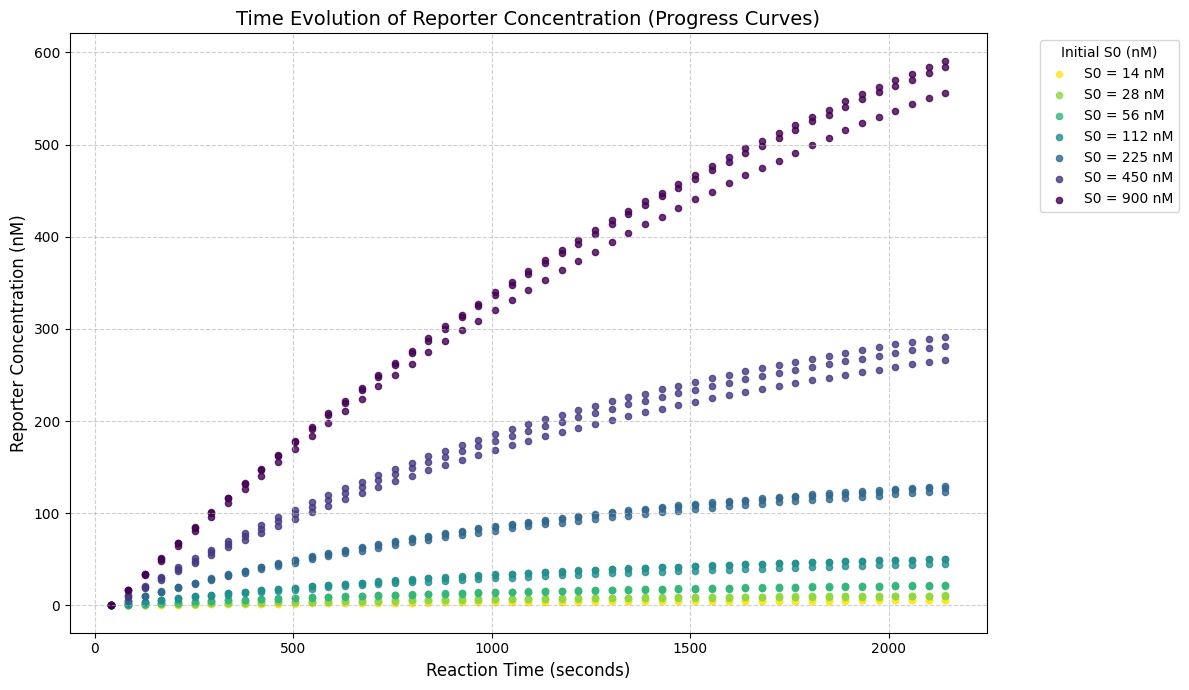

,Replicate,Substrate_nM,Initial_Rate_nM_per_s,R_squared,p_value,Slope_SE
0,D6,900.0,0.384380,0.999958,1.152515e-07,0.001437
1,D7,900.0,0.401036,0.999952,1.414454e-07,0.001605
2,D8,900.0,0.405483,0.999993,7.035006e-09,0.000597


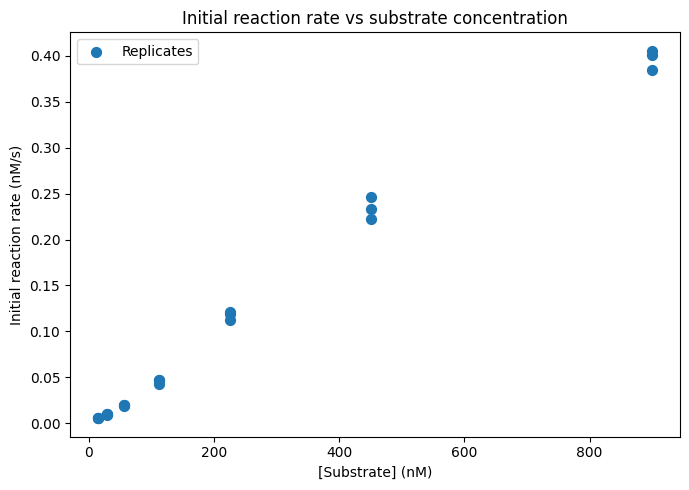

In [ ]:
# @title Initial Reation Rate Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import linregress

def plot_progress_curves(df, first_data_col=2, time_col="Time [s]"):
    first_col = df.columns[0]
    sub_row_df = df[df[first_col].astype(str).str.strip().str.lower() == "substrate"]

    if sub_row_df.empty:
        raise ValueError("Could not find a row labeled 'Substrate' in the uploaded file.")

    sub_row = sub_row_df.iloc[0]
    data_cols = [col for col in df.columns[first_data_col:] if pd.notna(sub_row[col])]

    substrate_map = {}
    for col in data_cols:
        substrate_map[col] = float(sub_row[col])

    clean_df = df.copy()
    clean_df = clean_df.drop(sub_row_df.index) # Remove the substrate row
    clean_df[time_col] = pd.to_numeric(clean_df[time_col], errors="coerce")
    clean_df = clean_df[clean_df[time_col].notna()].copy()

    for col in data_cols:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
    clean_df = clean_df.reset_index(drop=True)

    time_points = clean_df[time_col].to_numpy()

    plt.figure(figsize=(12, 7))

    unique_s0s = sorted(list(set(substrate_map.values())))
    cmap = cm.get_cmap('viridis_r', len(unique_s0s)) # Changed to viridis_r

    wells_by_s0 = {}
    for well, s0 in substrate_map.items():
        if s0 not in wells_by_s0:
            wells_by_s0[s0] = []
        wells_by_s0[s0].append(well)

    for i, s0_val in enumerate(unique_s0s):
        color = cmap(i)
        current_wells = wells_by_s0.get(s0_val, [])
        for well in current_wells:
            if well in clean_df.columns:
                plt.scatter(time_points, clean_df[well], color=color, s=20,
                            label=f'S0 = {s0_val:.0f} nM' if well == current_wells[0] else "", alpha=0.8)

    plt.xlabel("Reaction Time (seconds)", fontsize=12)
    plt.ylabel("Reporter Concentration (nM)", fontsize=12)
    plt.title("Time Evolution of Reporter Concentration (Progress Curves)", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Initial S0 (nM)", loc='best', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

def calculate_initial_rates(df, time_col="Time [s]", first_data_col=2, first_n_cycles=5):
    """
    Assumes:
    - one row contains substrate concentrations, labeled 'Substrate' in first column
    - time column is named like 'Time [s]'
    - replicate data start from first_data_col
    """

    # ---------- 1. get substrate map from 'Substrate' row ----------
    first_col = df.columns[0]
    sub_row = df[df[first_col].astype(str).str.strip().str.lower() == "substrate"]

    if sub_row.empty:
        raise ValueError("Could not find a row labeled 'Substrate'.")

    sub_row = sub_row.iloc[0]
    data_cols = list(df.columns[first_data_col:])

    substrate_map = {}
    for col in data_cols:
        if pd.notna(sub_row[col]):
            substrate_map[col] = float(sub_row[col])

    # ---------- 2. clean numeric data ----------
    clean_df = df.copy()
    clean_df[time_col] = pd.to_numeric(clean_df[time_col], errors="coerce")
    clean_df = clean_df[clean_df[time_col].notna()].copy()

    for col in data_cols:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

    clean_df = clean_df.reset_index(drop=True)

    # ---------- 3. use first N cycles ----------
    fit_df = clean_df.iloc[:first_n_cycles].copy()
    t = fit_df[time_col].to_numpy()

    results = []
    for col in data_cols:
        if col not in substrate_map:
            continue

        y = fit_df[col].to_numpy()

        if np.any(pd.isna(y)):
            continue

        fit = linregress(t, y)

        results.append({
            "Replicate": col,
            "Substrate_nM": substrate_map[col],
            "Initial_Rate_nM_per_s": fit.slope,
            "R_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
            "Slope_SE": fit.stderr
        })

    replicate_rate_df = pd.DataFrame(results).sort_values(["Substrate_nM", "Replicate"])

    grouped_rate_df = (
        replicate_rate_df.groupby("Substrate_nM", as_index=False)
        .agg(
            Mean_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "mean"),
            SD_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "std"),
            N=("Initial_Rate_nM_per_s", "count")
        )
        .sort_values("Substrate_nM")
        .reset_index(drop=True)
    )

    return replicate_rate_df, grouped_rate_df


def plot_initial_rates(replicate_rate_df):
    plt.figure(figsize=(7,5))

    plt.scatter(
        replicate_rate_df["Substrate_nM"],
        replicate_rate_df["Initial_Rate_nM_per_s"],
        s=50,
        label="Replicates"
    )

    plt.xlabel("[Substrate] (nM)")
    plt.ylabel("Initial reaction rate (nM/s)")
    plt.title("Initial reaction rate vs substrate concentration")
    plt.legend()
    plt.tight_layout()
    plt.show()



from google.colab import files
print("Upload your spreadsheet with varying substrate…")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.endswith(".xlsx") or file_name.endswith(".xls"):
    df = pd.read_excel(file_name)
elif file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
else:
    raise ValueError("Please upload an Excel or CSV file.")

# --- Call the new plotting function ---
first_data_col = 2
time_col = "Time [s]"
plot_progress_curves(df, first_data_col, time_col)
# --- End of plotting function call ---

replicate_rate_df, grouped_rate_df = calculate_initial_rates(df)

# display(df)
display(replicate_rate_df.tail(3))
# display(grouped_rate_df)

plot_initial_rates(replicate_rate_df)

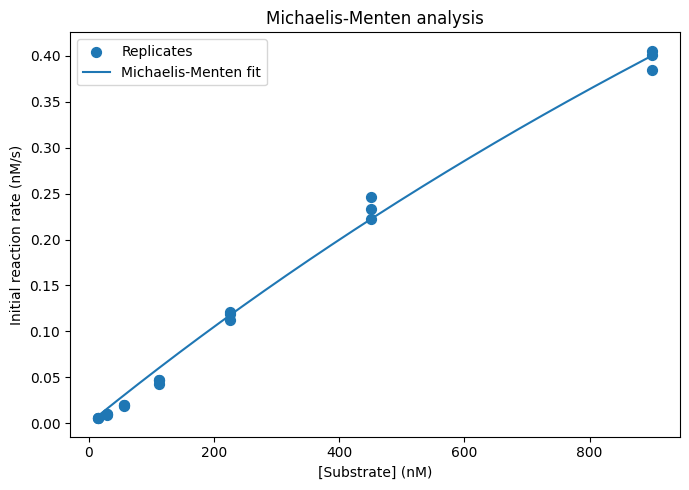

Vmax = 2.027474216822666
Km = 3659.34447737682
95% CI Vmax: (np.float64(1.108325196425525), np.float64(2.9466232372198067))
95% CI Km: (np.float64(1673.0927326701951), np.float64(5645.596222083445))
R² = 0.9943985965872895
Sum of Squares = 0.0021976942320035683
Sy.x = 0.010754911318735827
SD replicates = 0.006486238777651256
SD lack of fit = 0.01793709075225786
F = 7.64747641529677
P value = 0.0011850196831098003


In [ ]:
# @title Michaelis-Menten Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import f, t


# Michaelis-Menten model
def mm_model(S, Vmax, Km):
    S = np.asarray(S, dtype=float)
    return Vmax * S / (Km + S)


def run_mm_analysis_from_replicates(replicate_rate_df, make_plot=True):
    """
    Perform Michaelis-Menten analysis directly from replicate_rate_df.

    Required columns in replicate_rate_df:
    - Substrate_nM
    - Initial_Rate_nM_per_s

    Returns
    -------
    results_dict : dict
        Contains fitted parameters, statistics, and tables
    """

    # -------------------------
    # 1. Extract S and v
    # -------------------------
    df = replicate_rate_df.copy()

    if "Substrate_nM" not in df.columns or "Initial_Rate_nM_per_s" not in df.columns:
        raise ValueError("replicate_rate_df must contain 'Substrate_nM' and 'Initial_Rate_nM_per_s'.")

    df = df[["Substrate_nM", "Initial_Rate_nM_per_s"]].dropna().copy()
    df = df.sort_values("Substrate_nM").reset_index(drop=True)

    S = df["Substrate_nM"].to_numpy(dtype=float)
    v = df["Initial_Rate_nM_per_s"].to_numpy(dtype=float)

    if len(S) < 3:
        raise ValueError("Not enough data points for Michaelis-Menten fitting.")

    # -------------------------
    # 2. Nonlinear regression
    # -------------------------
    p0 = [np.max(v), np.median(S)]
    popt, pcov = curve_fit(mm_model, S, v, p0=p0, maxfev=10000)

    Vmax, Km = popt
    perr = np.sqrt(np.diag(pcov))
    Vmax_se, Km_se = perr

    # Predictions
    v_fit = mm_model(S, Vmax, Km)

    # -------------------------
    # 3. Goodness of fit
    # -------------------------
    residuals = v - v_fit
    SS_res = np.sum(residuals**2)
    SS_tot = np.sum((v - np.mean(v))**2)

    R2 = 1 - SS_res / SS_tot if SS_tot != 0 else np.nan

    n = len(v)
    p = 2
    dof = n - p

    Syx = np.sqrt(SS_res / dof) if dof > 0 else np.nan

    # -------------------------
    # 4. 95% confidence intervals
    # -------------------------
    tval = t.ppf(0.975, dof) if dof > 0 else np.nan

    Vmax_CI = (Vmax - tval * Vmax_se, Vmax + tval * Vmax_se) if dof > 0 else (np.nan, np.nan)
    Km_CI = (Km - tval * Km_se, Km + tval * Km_se) if dof > 0 else (np.nan, np.nan)

    # -------------------------
    # 5. Replicates test / lack of fit
    # -------------------------
    unique_S = np.unique(S)

    SS_pe = 0.0
    df_pe = 0

    for s in unique_S:
        vals = v[S == s]
        if len(vals) > 1:
            mean_val = np.mean(vals)
            SS_pe += np.sum((vals - mean_val)**2)
            df_pe += len(vals) - 1

    SS_lof = SS_res - SS_pe
    df_lof = dof - df_pe

    if df_pe > 0:
        MS_pe = SS_pe / df_pe
        SD_replicates = np.sqrt(MS_pe)
    else:
        MS_pe = np.nan
        SD_replicates = np.nan

    if df_lof > 0:
        MS_lof = SS_lof / df_lof
        SD_lof = np.sqrt(MS_lof) if MS_lof >= 0 else np.nan
    else:
        MS_lof = np.nan
        SD_lof = np.nan

    if df_pe > 0 and df_lof > 0 and MS_pe > 0:
        F_value = MS_lof / MS_pe
        p_value = 1 - f.cdf(F_value, df_lof, df_pe)
    else:
        F_value = np.nan
        p_value = np.nan

    # -------------------------
    # 6. Grouped summary table
    # -------------------------
    grouped_rate_df = (
        df.groupby("Substrate_nM", as_index=False)
        .agg(
            Mean_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "mean"),
            SD_Initial_Rate_nM_per_s=("Initial_Rate_nM_per_s", "std"),
            N=("Initial_Rate_nM_per_s", "count")
        )
        .sort_values("Substrate_nM")
        .reset_index(drop=True)
    )

    # Predicted curve for smooth plotting
    S_curve = np.linspace(np.min(S), np.max(S), 300)
    v_curve = mm_model(S_curve, Vmax, Km)

    # -------------------------
    # 7. Plot
    # -------------------------
    if make_plot:
        plt.figure(figsize=(7, 5))

        # replicate points
        plt.scatter(
            S,
            v,
            s=50,
            label="Replicates"
        )

        # fitted MM curve
        plt.plot(
            S_curve,
            v_curve,
            label="Michaelis-Menten fit"
        )

        plt.xlabel("[Substrate] (nM)")
        plt.ylabel("Initial reaction rate (nM/s)")
        plt.title("Michaelis-Menten analysis")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # -------------------------
    # 8. Results table
    # -------------------------
    summary_df = pd.DataFrame({
        "Parameter": [
            "Vmax",
            "Km",
            "Vmax_SE",
            "Km_SE",
            "Vmax_95CI_lower",
            "Vmax_95CI_upper",
            "Km_95CI_lower",
            "Km_95CI_upper",
            "R_squared",
            "SS_res",
            "Sy.x",
            "SD_replicates",
            "SD_lack_of_fit",
            "F_value",
            "P_value_replicates_test"
        ],
        "Value": [
            Vmax,
            Km,
            Vmax_se,
            Km_se,
            Vmax_CI[0],
            Vmax_CI[1],
            Km_CI[0],
            Km_CI[1],
            R2,
            SS_res,
            Syx,
            SD_replicates,
            SD_lof,
            F_value,
            p_value
        ]
    })

    # Print concise summary
    print("Vmax =", Vmax)
    print("Km =", Km)
    print("95% CI Vmax:", Vmax_CI)
    print("95% CI Km:", Km_CI)
    print("R² =", R2)
    print("Sum of Squares =", SS_res)
    print("Sy.x =", Syx)
    print("SD replicates =", SD_replicates)
    print("SD lack of fit =", SD_lof)
    print("F =", F_value)
    print("P value =", p_value)

    return {
        "input_df": df,
        "grouped_rate_df": grouped_rate_df,
        "summary_df": summary_df,
        "Vmax": Vmax,
        "Km": Km,
        "Vmax_SE": Vmax_se,
        "Km_SE": Km_se,
        "Vmax_CI": Vmax_CI,
        "Km_CI": Km_CI,
        "R_squared": R2,
        "SS_res": SS_res,
        "Syx": Syx,
        "SD_replicates": SD_replicates,
        "SD_lack_of_fit": SD_lof,
        "F_value": F_value,
        "P_value": p_value,
        "S_curve": S_curve,
        "v_curve": v_curve
    }
mm_results = run_mm_analysis_from_replicates(replicate_rate_df, make_plot=True)

In [ ]:
# @title Extract Variables (t_lin, v, S0, Vmax, KM) & Imput E0 to calculate kcat
# Assuming 'df', 'time_col', and 'first_n_cycles' are already defined in the global scope
# from previous cell executions.

# Define time_col and first_n_cycles explicitly for this cell's scope if not globally defined
time_col = "Time [s]"
first_n_cycles = 5

# Recreate clean_df from the global df, as it was created inside a function previously
clean_df = df.copy()
clean_df[time_col] = pd.to_numeric(clean_df[time_col], errors="coerce")
clean_df = clean_df[clean_df[time_col].notna()].copy()

# Identify data columns and convert them to numeric, similar to calculate_initial_rates
first_data_col = 2 # Default value from calculate_initial_rates function
data_cols = list(df.columns[first_data_col:])
for col in data_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
clean_df = clean_df.reset_index(drop=True)

# Extract the time points for the initial n cycles
fit_df = clean_df.iloc[:first_n_cycles].copy()
t_lin = fit_df[time_col].to_numpy()

# Extract and print only the maximum t_lin value
t_lin_max = t_lin.max()
print(f"Maximum time point for initial rate calculation (t_lin_max): {t_lin_max} s")

# Extract the maximum reaction velocity and its corresponding substrate concentration
max_rate_row = grouped_rate_df.loc[grouped_rate_df['Mean_Initial_Rate_nM_per_s'].idxmax()]

max_mean_reaction_velocity = max_rate_row['Mean_Initial_Rate_nM_per_s']
S0_at_max_velocity = max_rate_row['Substrate_nM']

print(f"Reported Max Initial Reaction Rate: {max_mean_reaction_velocity:.4f} nM/s")
print(f"Substrate Concentration (S0) at Max Rate: {S0_at_max_velocity:.2f} nM")

# Initialize Vmax and Km to None in case mm_results is not defined
Vmax = None
Km = None

try:
    # Extract Vmax and KM
    print(f"Vmax: {mm_results['Vmax']:.4f} nM/s")
    print(f"KM: {mm_results['Km']:.2f} nM")

    # Extract Vmax and Km from the mm_results dictionary
    Vmax = mm_results['Vmax']
    Km = mm_results['Km']

except NameError:
    print("Error: The 'mm_results' variable is not defined. Please ensure the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K) has been executed before running this cell.")
except KeyError as e:
    print(f"Error: Missing key '{e}' in mm_results dictionary. Please check the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K).")


# Ask the user for the initial enzyme concentration (E0)
E0_str = input("Please enter the fixed concentration (nM) of E0: ")

try:
    E0 = float(E0_str)
    if E0 <= 0:
        raise ValueError("E0 must be a positive value.")
except ValueError as e:
    print(f"Invalid input for E0: {e}")
    print("Please run this cell again and enter a valid positive number for E0.")
    E0 = None # Set E0 to None to prevent further calculations if invalid

if E0 is not None and Vmax is not None: # Add check for Vmax
    # Calculate kcat
    kcat = Vmax / E0
    print(f"\nCalculated kcat = {kcat:.4f} 1/s (Vmax in nM/s and E0 in nM).")
else:
    if Vmax is None:
        print("\nkcat cannot be calculated because Vmax is not available. Please address the error regarding 'mm_results'.")
    elif E0 is None:
        print("\nkcat cannot be calculated because E0 is not valid.")


Maximum time point for initial rate calculation (t_lin_max): 210.0 s
Reported Max Initial Reaction Rate: 0.3970 nM/s
Substrate Concentration (S0) at Max Rate: 900.00 nM
Vmax: 2.0275 nM/s
KM: 3659.34 nM
Please enter the fixed concentration (nM) of E0: 1

Calculated kcat = 2.0275 1/s (Vmax in nM/s and E0 in nM).


In [ ]:
# @title Self-Consistency Check for alpha, beta, gamma
import numpy as np

try:
    # Extract Vmax and Km from mm_results dictionary
    Vmax = mm_results['Vmax']
    Km = mm_results['Km']

    # Calculate alpha, beta, and gamma
    alpha = max_mean_reaction_velocity * t_lin_max / S0_at_max_velocity
    beta = max_mean_reaction_velocity / Vmax
    gamma = t_lin_max * Vmax / (Km + S0_at_max_velocity * (1 - 1/np.e))

    print(f"alpha = {alpha:.4f}")
    print(f"beta = {beta:.4f}")
    print(f"gamma = {gamma:.4f}")
except NameError:
    print("Error: The 'mm_results' variable is not defined. Please ensure the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K) has been executed before running this cell.")
except KeyError:
    print("Error: 'Vmax' or 'Km' not found in 'mm_results'. Please check the 'Michaelis-Menten Analysis' cell (cell ID: nCTkA5w_-48K).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Varing Target Concentration

In [ ]:
# @title Upload the Table
import numpy as np
import pandas as pd
from google.colab import files

print("Upload your 'Varying Target Concentration' spreadsheet:")
uploaded = files.upload()

target_file_name = list(uploaded.keys())[0]
print("Varying Target Concentration file set to:", target_file_name)

if target_file_name.endswith(".xlsx") or target_file_name.endswith(".xls"):
    df_tar = pd.read_excel(target_file_name)
elif target_file_name.endswith(".csv"):
    df_tar = pd.read_csv(target_file_name)
else:
    raise ValueError("Please upload an Excel (.xlsx, .xls) or CSV (.csv) file for Varying Target Concentration.")

print(f"df_tar loaded with shape: {df_tar.shape}")
display(df_tar.head())

Upload your 'Varying Target Concentration' spreadsheet:


Saving VaryingTarget.xlsx to VaryingTarget.xlsx
Varying Target Concentration file set to: VaryingTarget.xlsx
df_tar loaded with shape: (53, 23)


,Unnamed: 0,Time [s],D2,D3,D4,F2,F3,F4,H2,H3,...,J4,L2,L3,L4,N2,N3,N4,P2,P3,P4
0,0,42.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025810,0.000000,...,0.000000,0.000000,0.059078,0.000000,0.000000,0.000000,0.041556,0.000000,0.054272,0.108596
1,1,84.0,1.326535,1.332337,1.490683,0.081980,0.126945,0.162862,0.000000,0.019540,...,0.013938,0.036748,0.000000,0.008588,0.015942,0.046691,0.000000,0.109192,0.000000,0.009843
2,2,126.0,2.837988,2.476689,2.988260,0.320674,0.231852,0.281141,0.097964,0.032890,...,0.037422,0.048560,0.052159,0.042544,0.015738,0.140609,0.062123,0.106904,0.057849,0.000000
3,3,168.0,4.136411,3.653279,4.428380,0.435921,0.346098,0.407657,0.031722,0.036366,...,0.079319,0.071145,0.111303,0.054487,0.023111,0.110647,0.015794,0.146309,0.046619,0.068578
4,4,210.0,5.399532,4.820133,5.802226,0.620466,0.538633,0.558231,0.096687,0.125282,...,0.077564,0.141538,0.118661,0.112701,0.067511,0.125112,0.084097,0.235668,0.060191,0.111763


In [ ]:
# @title Extract Endpoint Signals and Target Concentrations
first_col = df_tar.columns[0]
target_row_df = df_tar[df_tar[first_col].astype(str).str.strip().str.lower().str.contains("target")]

# Assuming time_col is already defined from previous cells
# If not, let's define it based on common practice or inspect df_tar
if 'Time [s]' in df_tar.columns:
    time_col = 'Time [s]'
elif 'Time' in df_tar.columns:
    time_col = 'Time'
else:
    # Fallback if neither 'Time [s]' nor 'Time' is found in df_tar
    # This might need adjustment based on actual df_tar structure
    time_col = df_tar.columns[1] # Assuming time is the second column

# Identify data columns (wells) excluding the first column and the time column
data_cols_tar = [col for col in df_tar.columns if col != first_col and col != time_col]

target_concentration_map = {}
endpoint_signals = {} # Renamed from endpoint_concentrations

target_row_index = -1
if not target_row_df.empty:
    target_row_tar = target_row_df.iloc[0]
    target_row_index = target_row_tar.name # Get the actual index of the target row

    for col in data_cols_tar:
        # Extract Target Concentration
        if pd.notna(target_row_tar[col]):
            target_concentration_map[col] = float(target_row_tar[col])
        else:
            target_concentration_map[col] = np.nan # Handle missing target concentration
else:
    print("Warning: Could not find a row labeled 'Target' in df_tar. Target concentrations will be set to NaN.")
    for col in data_cols_tar:
        target_concentration_map[col] = np.nan

for col in data_cols_tar:
    # Extract Endpoint Signal (last value in the time-series data, BEFORE the target row)
    if target_row_index != -1:
        # Time-series data is from row 0 up to target_row_index - 1
        relevant_data = df_tar[col].iloc[:target_row_index]
    else:
        # If no target row, assume all data is time-series
        relevant_data = df_tar[col]

    numeric_values = pd.to_numeric(relevant_data, errors='coerce').dropna()
    if not numeric_values.empty:
        endpoint_signals[col] = numeric_values.iloc[-1]
    else:
        endpoint_signals[col] = np.nan

# Create a new DataFrame
results_list = []
for well in data_cols_tar:
    results_list.append({
        'Well': well,
        'Target_Concentration_nM': target_concentration_map.get(well),
        'Endpoint_Signal_AU': endpoint_signals.get(well) # Renamed column
    })

target_endpoint_df = pd.DataFrame(results_list)

print("Extracted Target Concentrations and Endpoint Signals:") # Updated print statement
display(target_endpoint_df.head())

Extracted Target Concentrations and Endpoint Signals:


,Well,Target_Concentration_nM,Endpoint_Signal_AU
0,D2,10.0,43.907516
1,D3,10.0,40.120748
2,D4,10.0,47.700965
3,F2,1.0,6.076316
4,F3,1.0,5.337113


Mean Endpoint Signal for lowest target concentration (1.00e-05 nM): 0.5657 nM
Standard Deviation of Endpoint Signal for lowest target concentration (1.00e-05 nM): 0.0339 nM
Endpoint Threshold Value (P_thr): 0.6675 nM


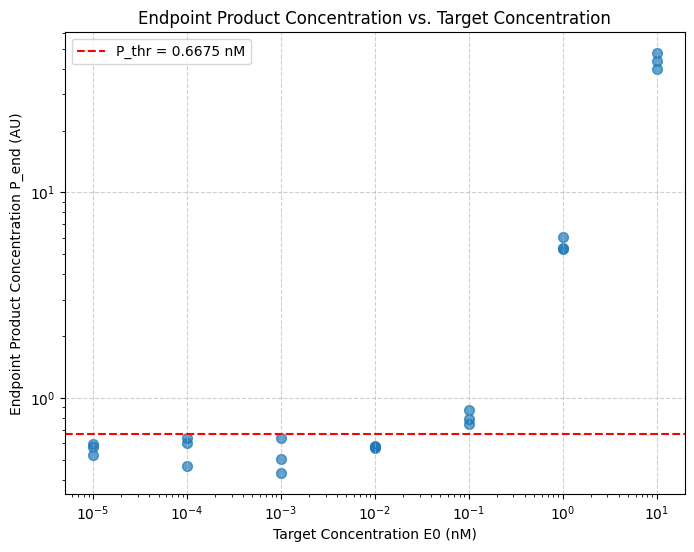

In [ ]:
import matplotlib.pyplot as plt

# Find the smallest target concentration (which might not be 0)
min_target_concentration = target_endpoint_df['Target_Concentration_nM'].min()

# Filter for data corresponding to the smallest target concentration
ntc_data = target_endpoint_df[target_endpoint_df['Target_Concentration_nM'] == min_target_concentration]

# Calculate the mean of Endpoint_Signal_AU for ntc_data
mean_ntc_signal = ntc_data['Endpoint_Signal_AU'].mean()

# Calculate the standard deviation of Endpoint_Signal_AU for ntc_data
std_ntc_signal = ntc_data['Endpoint_Signal_AU'].std()

# Calculate the threshold value (P_thr) using the provided formula
P_thr = mean_ntc_signal + 3 * std_ntc_signal

# Conditional printing based on min_target_concentration
if min_target_concentration == 0:
    print(f"Mean Endpoint Signal for E0=0 (P(E0=0)): {mean_ntc_signal:.4f} nM")
    print(f"Standard Deviation of Endpoint Signal for E0=0 (STD(E0=0)): {std_ntc_signal:.4f} nM")
    print(f"Endpoint Threshold Value (P_thr): {P_thr:.4f} nM")
else:
    print(f"Mean Endpoint Signal for lowest target concentration ({min_target_concentration:.2e} nM): {mean_ntc_signal:.4f} nM")
    print(f"Standard Deviation of Endpoint Signal for lowest target concentration ({min_target_concentration:.2e} nM): {std_ntc_signal:.4f} nM")
    print(f"Endpoint Threshold Value (P_thr): {P_thr:.4f} nM")

plt.figure(figsize=(8, 6))
plt.scatter(target_endpoint_df['Target_Concentration_nM'], target_endpoint_df['Endpoint_Signal_AU'], s=50, alpha=0.7)
plt.xscale('log') # Set x-axis to logarithmic scale
plt.yscale('log')
plt.xlabel("Target Concentration E0 (nM)")
plt.ylabel("Endpoint Product Concentration P_end (AU)")
plt.title("Endpoint Product Concentration vs. Target Concentration")
plt.grid(True, linestyle='--', alpha=0.6)

# Draw a horizontal line at y = P_thr
plt.axhline(y=P_thr, color='r', linestyle='--', label=f'P_thr = {P_thr:.4f} nM')
plt.legend()

plt.show()

In [ ]:
# @title Determine Endpoint LoD
from scipy.interpolate import interp1d
import numpy as np

# Prepare data for interpolation
# Ensure data is sorted by target concentration for correct interpolation
sorted_data = target_endpoint_df.sort_values(by='Target_Concentration_nM').reset_index(drop=True)

x_values = sorted_data['Target_Concentration_nM'].to_numpy()
y_values = sorted_data['Endpoint_Signal_AU'].to_numpy()

# Filter out NaN values from both arrays, keeping corresponding pairs
valid_indices = ~np.isnan(x_values) & ~np.isnan(y_values)
x_values = x_values[valid_indices]
y_values = y_values[valid_indices]

# Ensure there are enough points for interpolation
if len(x_values) < 2:
    print("Not enough valid data points for interpolation to determine LoD.")
    LoD = np.nan
else:
    # Create an interpolation function: y = f(x)
    # Since we want x (Target_Concentration) for a given y (P_thr), we interpolate x as a function of y.
    # Handle cases where P_thr might be outside the range of y_values
    if P_thr < np.min(y_values):
        print(f"P_thr ({P_thr:.4f}) is below the minimum Endpoint Signal ({np.min(y_values):.4f}). LoD cannot be accurately determined by interpolation below data range.")
        LoD = np.nan
    elif P_thr > np.max(y_values):
        print(f"P_thr ({P_thr:.4f}) is above the maximum Endpoint Signal ({np.max(y_values):.4f}). LoD cannot be accurately determined by interpolation above data range.")
        LoD = np.nan
    else:
        # Ensure x_values (Target_Concentration_nM) are unique for interp1d when interpolating y to x
        # If not unique, average y_values for duplicate x_values, or use a specific interpolation strategy
        # For this context, we assume a monotonic relationship for LoD determination and interpolate X as a function of Y
        # To interpolate X as a function of Y, Y values should ideally be monotonic. If not, this can cause issues.
        # Let's assume we want to interpolate in the region where the curve is generally increasing.

        # To make Y monotonic for interpolation (Y_to_X), we might need to select a subset or ensure it's sorted.
        # For LoD, we are looking for a specific Y value (P_thr) corresponding to an X value.
        # Let's create an interpolation function from y to x
        f_interp = interp1d(y_values, x_values, kind='linear', fill_value="extrapolate")

        # Determine LoD by finding the target concentration at P_thr
        LoD = f_interp(P_thr)

print(f"\nCalculated Endpoint Limit of Detection (LoD): {LoD:.4f} nM")



Calculated Endpoint Limit of Detection (LoD): 0.0267 nM


## Extract Initial Reaction Rates

In [ ]:
# @title
import numpy as np
import pandas as pd
from scipy.stats import linregress

def calculate_initial_rates_from_df_tar(df_tar, time_col="Time [s]", first_n_cycles=5):
    """
    Calculates initial reaction rates for each well in df_tar.
    Assumes:
    - one row contains target concentrations, labeled 'Target' in the first column (or containing 'target').
    - time column is named 'Time [s]'.
    - time-series data precedes the 'Target' row.
    """
    first_col = df_tar.columns[0]
    # Changed to use .str.contains("target") for consistency
    target_row_df = df_tar[df_tar[first_col].astype(str).str.strip().str.lower().str.contains("target")]

    target_concentration_map = {}
    # Identify data columns by excluding the first column and time_col
    data_cols_tar = [col for col in df_tar.columns if col != first_col and col != time_col]

    if not target_row_df.empty:
        target_row_tar = target_row_df.iloc[0]
        for col in data_cols_tar:
            if pd.notna(target_row_tar[col]):
                target_concentration_map[col] = float(target_row_tar[col])
            else:
                target_concentration_map[col] = np.nan # Handle missing target concentration
    else:
        print("Warning: Could not find a row containing 'Target'. Target concentrations will be set to NaN.")
        for col in data_cols_tar:
            target_concentration_map[col] = np.nan

    clean_df_tar = df_tar.copy()
    # Filter out the target row from the main dataframe before processing time-series data
    if not target_row_df.empty:
        clean_df_tar = clean_df_tar.drop(target_row_df.index)

    clean_df_tar[time_col] = pd.to_numeric(clean_df_tar[time_col], errors="coerce")
    clean_df_tar = clean_df_tar[clean_df_tar[time_col].notna()].copy() # Ensure time is valid

    for col in data_cols_tar:
        clean_df_tar[col] = pd.to_numeric(clean_df_tar[col], errors="coerce")

    clean_df_tar = clean_df_tar.reset_index(drop=True)

    # Use first N cycles for linear regression
    fit_df_tar = clean_df_tar.iloc[:first_n_cycles].copy()
    t = fit_df_tar[time_col].to_numpy()

    results = []
    for col in data_cols_tar:
        y = fit_df_tar[col].to_numpy()

        # Ensure there's enough non-NaN data for linear regression
        valid_indices = ~np.isnan(t) & ~np.isnan(y)
        t_valid = t[valid_indices]
        y_valid = y[valid_indices]

        if len(t_valid) < 2:
            initial_rate = np.nan
            r_squared = np.nan
        else:
            fit = linregress(t_valid, y_valid)
            initial_rate = fit.slope
            r_squared = fit.rvalue**2

        results.append({
            "Well": col,
            "Target_Concentration_nM": target_concentration_map.get(col, np.nan),
            "Initial_Rate_nM_per_s": initial_rate,
            "R_squared": r_squared,
        })

    replicate_rate_df_tar = pd.DataFrame(results)
    return replicate_rate_df_tar

# Call the function with df_tar and display the results
replicate_rate_df_tar = calculate_initial_rates_from_df_tar(df_tar)
print("Initial Reaction Rates from df_tar:")
display(replicate_rate_df_tar.head())

Initial Reaction Rates from df_tar:


,Well,Target_Concentration_nM,Initial_Rate_nM_per_s,R_squared
0,D2,10.0,0.032402,0.999038
1,D3,10.0,0.028479,0.999264
2,D4,10.0,0.034624,0.999686
3,F2,1.0,0.003797,0.982861
4,F3,1.0,0.003087,0.985707


Mean Initial Reaction Rate for lowest target concentration (0.0000 nM): 0.0005 nM/s
Standard Deviation of Initial Reaction Rate for lowest target concentration (0.0000 nM): 0.0006 nM/s
Rate-based Threshold (Rate_thr): 0.0023 nM/s


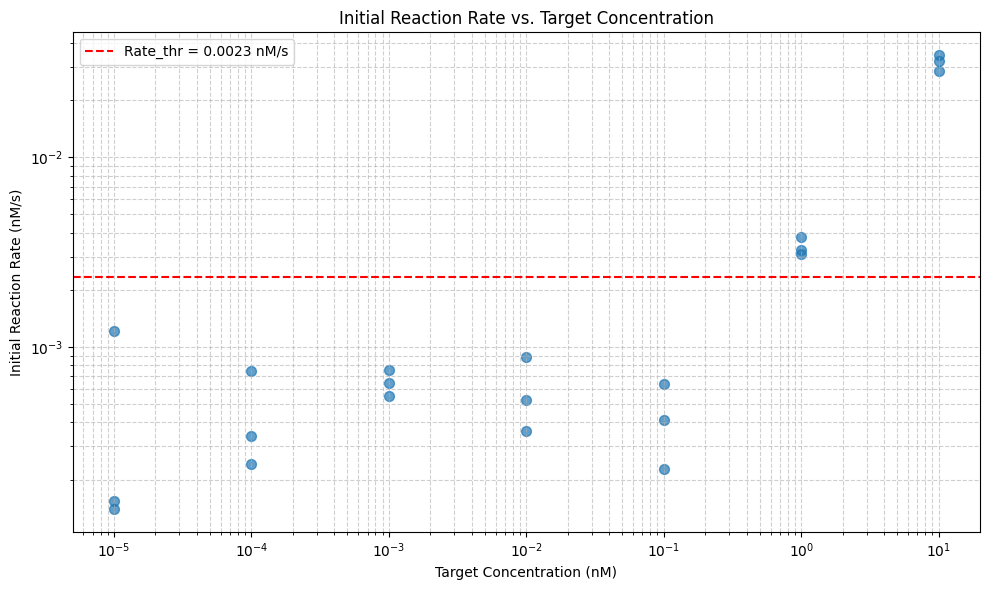

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt # Import plt again, good practice for separate cells

# Find the smallest target concentration (which might not be 0)
min_target_concentration_rates = replicate_rate_df_tar['Target_Concentration_nM'].min()

# Filter for NTC (No Target Control) data where Target_Concentration_nM is the smallest
ntc_rates_data = replicate_rate_df_tar[replicate_rate_df_tar['Target_Concentration_nM'] == min_target_concentration_rates]

# Calculate the mean of 'Initial_Rate_nM_per_s' for NTC data
mean_ntc_rate = ntc_rates_data['Initial_Rate_nM_per_s'].mean()

# Calculate the standard deviation of 'Initial_Rate_nM_per_s' for NTC data
std_ntc_rate = ntc_rates_data['Initial_Rate_nM_per_s'].std()

# Compute the Rate_thr
Rate_thr = mean_ntc_rate + 3 * std_ntc_rate

# Conditional printing based on min_target_concentration_rates
if min_target_concentration_rates == 0:
    print(f"Mean Initial Reaction Rate for NTC (E0=0): {mean_ntc_rate:.4f} nM/s")
    print(f"Standard Deviation of Initial Reaction Rate for NTC (E0=0): {std_ntc_rate:.4f} nM/s")
    print(f"Rate-based Threshold (Rate_thr): {Rate_thr:.4f} nM/s")
else:
    print(f"Mean Initial Reaction Rate for lowest target concentration ({min_target_concentration_rates:.4f} nM): {mean_ntc_rate:.4f} nM/s")
    print(f"Standard Deviation of Initial Reaction Rate for lowest target concentration ({min_target_concentration_rates:.4f} nM): {std_ntc_rate:.4f} nM/s")
    print(f"Rate-based Threshold (Rate_thr): {Rate_thr:.4f} nM/s")

plt.figure(figsize=(10, 6))
plt.scatter(replicate_rate_df_tar['Target_Concentration_nM'], replicate_rate_df_tar['Initial_Rate_nM_per_s'], s=50, alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Target Concentration (nM)")
plt.ylabel("Initial Reaction Rate (nM/s)")
plt.title("Initial Reaction Rate vs. Target Concentration")
plt.grid(True, which="both", ls="--", alpha=0.6)

# Add horizontal line for Rate_thr
plt.axhline(y=Rate_thr, color='r', linestyle='--', label=f'Rate_thr = {Rate_thr:.4f} nM/s')
plt.legend()

plt.tight_layout()
plt.show()

## Determine Rate-based LoD


In [ ]:
# @title
from scipy.interpolate import interp1d
import numpy as np

# Prepare data for interpolation
sorted_rates_data = replicate_rate_df_tar.sort_values(by='Target_Concentration_nM').reset_index(drop=True)

x_rates = sorted_rates_data['Initial_Rate_nM_per_s'].to_numpy()
y_concentrations = sorted_rates_data['Target_Concentration_nM'].to_numpy()

# Filter out NaN values from both arrays, keeping corresponding pairs
valid_indices = ~np.isnan(x_rates) & ~np.isnan(y_concentrations)
x_rates = x_rates[valid_indices]
y_concentrations = y_concentrations[valid_indices]

# Ensure there are enough points for interpolation
if len(x_rates) < 2:
    print("Not enough valid data points for interpolation to determine rate-based LoD.")
    rate_based_LoD = np.nan
elif Rate_thr < np.min(x_rates):
    print(f"Rate_thr ({Rate_thr:.4f}) is below the minimum Initial Reaction Rate ({np.min(x_rates):.4f}). Rate-based LoD cannot be accurately determined by interpolation below data range.")
    rate_based_LoD = np.nan
elif Rate_thr > np.max(x_rates):
    print(f"Rate_thr ({Rate_thr:.4f}) is above the maximum Initial Reaction Rate ({np.max(x_rates):.4f}). Rate-based LoD cannot be accurately determined by interpolation above data range.")
    rate_based_LoD = np.nan
else:
    # Create an interpolation function: concentration = f(rate)
    # Ensure x_rates are monotonic for interp1d
    # If there are duplicate x_rates, interp1d will raise an error if they are not strictly increasing.
    # For this specific case (LoD), we expect rates to generally increase with concentration.
    # If not strictly increasing, we can try to average y values for duplicate x values, or accept non-monotonicity if it makes sense.
    # For now, assuming x_rates are sufficiently unique or sorted to allow interpolation.
    f_interp_rate = interp1d(x_rates, y_concentrations, kind='linear', fill_value="extrapolate")

    # Determine rate-based LoD by finding the target concentration at Rate_thr
    rate_based_LoD = f_interp_rate(Rate_thr)

print(f"\nCalculated Rate-based Limit of Detection (LoD): {rate_based_LoD:.4f} nM")


Calculated Rate-based Limit of Detection (LoD): 0.6040 nM
